['5.webp', '9.webp', '8.webp', '4.webp', '3.webp', '2.webp', '1.webp', '10.webp', '0.webp', '7.webp', '6.webp']


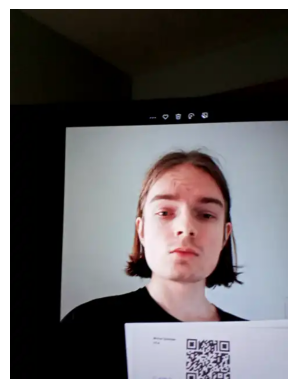

In [1]:
# Opracowanie altrnatywnego sposobu wykrywania ramek
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import cv2.data

# Załadowanie przykładów
#image_path = "../../../Dane/Sample/Phone"
image_path = "../../../Dane/Sample/zd"
#image_path = "../../../Dane/Sample/Default"
files = [f for f in os.listdir(image_path) if f.endswith(".jpg") or f.endswith("jpeg") or f.endswith(".png") or f.endswith(".webp")] # Tylko pliki JPG i PNG i WEBP
print(files)

images = []

for f in files:
    image = cv2.imread(os.path.join(image_path, f))
    images.append(image)

image = images[0]
#image = cv2.imread("../../../Dane/Sample/Dostrajanie wykrywania ramek/Zdjęcie, 28.05.2024 o 12.37.jpg")

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

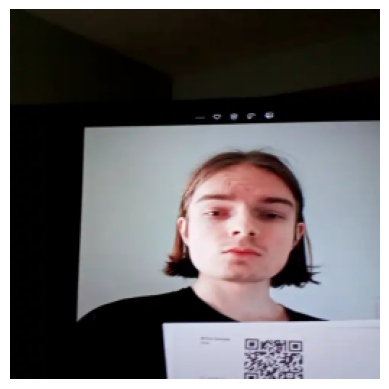

In [2]:
# 0. Downscale
img_downscaled = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)
plt.imshow(cv2.cvtColor(img_downscaled, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

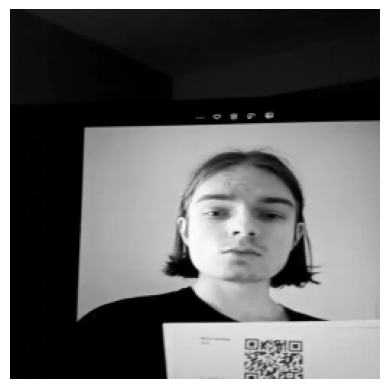

In [3]:
# Wykrycie twarzy
face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

image = img_downscaled

# [PARAMETRY]
face = face_classifier.detectMultiScale(image, scaleFactor=1.1, minNeighbors=5)[0]

# Konwersja na skalę szarości
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

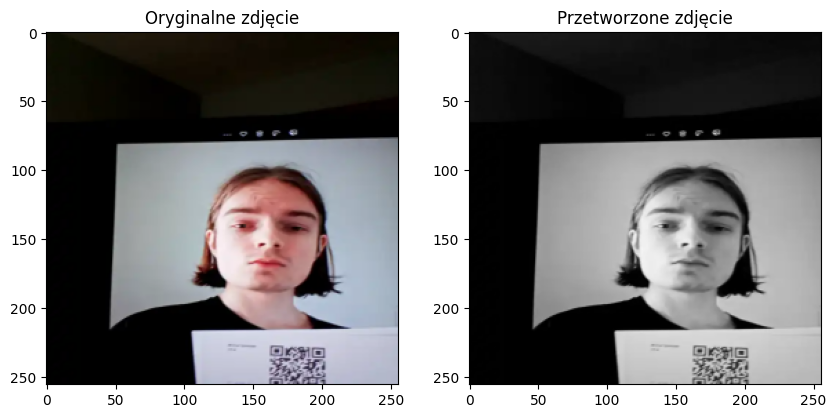

In [4]:
# Do pracy: porównanie oryginalnego i downscaled zdjęcia
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title("Oryginalne zdjęcie")

ax[1].imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
ax[1].set_title("Przetworzone zdjęcie")

plt.show()

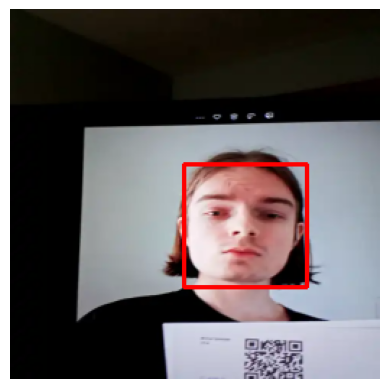

In [5]:
# Wyświetlenie twarzy
cv2.rectangle(image, (face[0], face[1]), (face[0] + face[2], face[1] + face[3]), (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

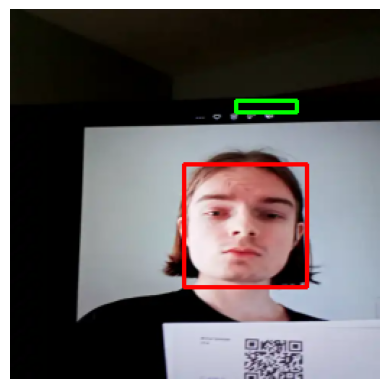

In [6]:
# 1. Ustalenie parametrów początkowych
# 2. Sprawdzenie obecności ramki w "górę"
# 3. Stopniowa zmiana parametrów do minimalnego progu
# 4. Powtórzenie kroku dla pozostałych trzech krawędzi
# ZMIANA: Sprawdzanie pikseli zaczynamy od miejsca początku twarzy, i obszar ten zmieniamy aż do końca twarzy
# (w każdą stronę)
# Wielkość ramki ustalamy na 1/2 szerokości/wysokości twarzy
x, y, w, h = face

# Zmienne dla wszystkich czterech kierunków
bezels_found = 0
face_width = w
face_height = h
max_bezel_size = 30
min_bezel_size = 8
gray_threshold = 28

# Zmienne dla pętli zewnętrznej
candidates = []
x_start = 0
x_end = 0
x_size = w // 2
i = 0

# Sprawdzanie pikseli "w górę"
while x_end < x + w:
    x_start = x + i
    y_start = 0
    x_end = x_start + x_size
    y_end = y
    current_bezel_size = max_bezel_size
    
    while current_bezel_size >= min_bezel_size:
        # Wybieramy "pasek" o szerokości current_bezel_size
        bezel = gray[y_start:y_start + current_bezel_size, x_start:x_end]
        # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
        average = np.mean(bezel)
        if average <= gray_threshold:
            candidates.append((x_start, y_start, x_end, y_start + current_bezel_size, average))
    
        # Przesunięcie paska
        y_start += 1
    
        if y_start + current_bezel_size >= y_end:
            current_bezel_size -= 1
            y_start = 0
            
    i += 1
        

# Wybieramy kandydata (jeżeli istnieje) o najmniejszej średniej wartości pikseli
if len(candidates) > 0:
    x_start, y_start, x_end, y_end, _ = min(candidates, key=lambda a: a[4])
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
    bezels_found += 1
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [7]:
# Powtarzamy dla pozostałych krawędzi
# W "dół"
# Zmienne dla pętli zewnętrznej
candidates = []
x_start = 0
x_end = 0
x_size = w // 2
i = 0

while x_end < x + w:
    x_start = x + i
    y_start = y + h
    x_end = x_start + x_size
    y_end = 256
    current_bezel_size = max_bezel_size

    while current_bezel_size >= min_bezel_size:
        # Wybieramy "pasek" o szerokości current_bezel_size
        bezel = gray[y_start:y_start + current_bezel_size, x_start:x_end]
        # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
        average = np.mean(bezel)
        if average <= gray_threshold:
            candidates.append((x_start, y_start, x_end, y_start + current_bezel_size, average))
        
        # Przesunięcie paska
        y_start += 1
        
        if y_start + current_bezel_size >= y_end:
            current_bezel_size -= 1
            y_start = y
            
    i += 1

# Wybieramy kandydata (jeżeli istnieje) o najmniejszej średniej wartości pikseli
if len(candidates) > 0:
    x_start, y_start, x_end, y_end, _ = min(candidates, key=lambda a: a[4])
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
    bezels_found += 1
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

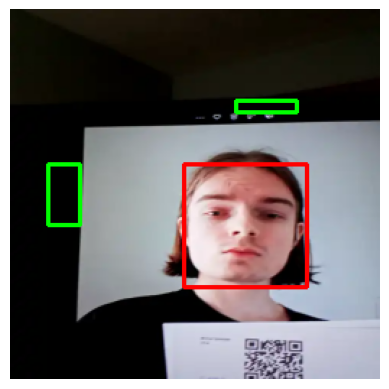

In [8]:
# W "lewo"
# Zmienne dla pętli zewnętrznej
candidates = []
y_start = 0
y_end = 0
y_size = h // 2
i = 0

while y_end < y + h:
    x_start = 0
    y_start = y + i
    x_end = x
    y_end = y_start + y_size
    current_bezel_size = max_bezel_size
    
    while current_bezel_size >= min_bezel_size:
        # Wybieramy "pasek" o szerokości current_bezel_size
        bezel = gray[y_start:y_end, x_start:x_start + current_bezel_size]
        # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
        average = np.mean(bezel)
        if average <= gray_threshold:
            candidates.append((x_start, y_start, x_start + current_bezel_size, y_end, average))
        
        # Przesunięcie paska
        x_start += 1
        
        if x_start + current_bezel_size >= x_end:
            current_bezel_size -= 1
            x_start = 0
            
    i += 1

# Wybieramy kandydata (jeżeli istnieje) o najmniejszej średniej wartości pikseli
if len(candidates) > 0:
    x_start, y_start, x_end, y_end, _ = min(candidates, key=lambda a: a[4])
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
    bezels_found += 1
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [9]:
# W "prawo"
# Zmienne dla pętli zewnętrznej
candidates = []
y_start = 0
y_end = 0
y_size = h // 2
i = 0

while y_end < y + h:
    x_start = x + w
    y_start = y + i
    x_end = 256
    y_end = y_start + y_size
    current_bezel_size = max_bezel_size
    
    while current_bezel_size >= min_bezel_size:
        # Wybieramy "pasek" o szerokości current_bezel_size
        bezel = gray[y_start:y_end, x_start:x_start + current_bezel_size]
        # Sprawdzamy, czy średnia wartość pikseli w pasku jest mniejsza niż próg
        average = np.mean(bezel)
        if average <= gray_threshold:
            candidates.append((x_start, y_start, x_start + current_bezel_size, y_end, average))
        
        # Przesunięcie paska
        x_start += 1
        
        if x_start + current_bezel_size >= x_end:
            current_bezel_size -= 1
            x_start = x
            
    i += 1
        
# Wybieramy kandydata (jeżeli istnieje) o najmniejszej średniej wartości pikseli
if len(candidates) > 0:
    x_start, y_start, x_end, y_end, _ = min(candidates, key=lambda a: a[4])
    cv2.rectangle(image, (x_start, y_start), (x_end, y_end), (0, 255, 0), 2)
    bezels_found += 1
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [10]:
# Sprawdzamy, ile ramek udało się znaleźć
# Jeżeli co najmniej 2, to uznajemy, że znaleźliśmy ramkę urządzenia
if bezels_found >= 2:
    print("Znaleziono ramkę")
else:
    print("Nie znaleziono ramki")

Znaleziono ramkę
